In [1]:
import os
import numpy as np
import scvelo as scv
import scanpy as sc

import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ''
DATA_NAME = 'curio-seq-embryoid'

In [3]:
adata = sc.read(os.path.join(DATA_DIR, f'{DATA_NAME}_pp.h5ad'))

In [4]:
FIG_DIR='./figures/curio-seq-embryoid'
MODEL_DIR = './checkpoints/curio-seq-embryoid'
DATA_DIR = ''

# (Optional) Spatial Graph

Ball Tree: average number of neighbors: 14.5


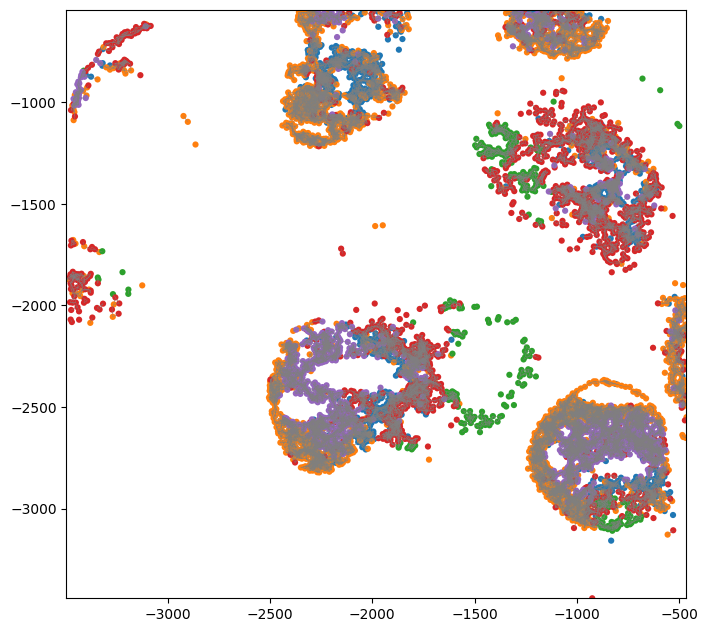

In [8]:
tpv.build_spatial_graph(adata, 'X_spatial', method='BallTree', radius=36.5)
tpv.plotting.plot_spatial_graph(adata, basis='spatial', width=8)

# TopoVelo (GAT)

In [11]:
figure_path = f'{FIG_DIR}/gat'
model_path = f'{MODEL_DIR}/gat'

vae = tpv.VAE(
    adata, 
    tmax=20, 
    dim_z=5, 
    device='cuda:0',
    graph_decoder=True,
    attention=True
)
config = {
    
}
vae.train(
    adata,
    adata.obsp['spatial_graph'],
    'X_spatial',
    config=config,
    plot=False,
    figure_path=figure_path,
    embed='spatial'
)
vae.save_model(model_path, 'encoder', 'decoder')
vae.save_anndata(adata, 'gat', DATA_DIR, file_name="adata_out.h5ad")

Estimating ODE parameters...


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/66 [00:00<?, ?it/s]

Reinitialize the regular ODE parameters based on estimated global latent time.


  0%|          | 0/66 [00:00<?, ?it/s]

*********               Creating a Graph Dataset              *********
*********                      Finished.                      *********
--------------------------- Train a TopoVelo ---------------------------
*********                 Creating optimizers                 *********
*********                      Finished.                      *********
*********                    Start training                   *********
*********                      Stage  1                       *********
*********       Stage 1: Early Stop Triggered at epoch 186.       *********
Summary: 
Train ELBO = 166.408
Test ELBO = 165.591
Total Time =   0 h : 11 m : 58 s

*********                      Stage  2                       *********


Calculating KNN:   0%|          | 0/5559 [00:00<?, ?it/s]

Stage 2: Early Stop Triggered at round 6.
Final: Train ELBO = 340.363,	Test ELBO = 340.497
*********              Finished. Total Time =   0 h : 26 m : 31 s             *********
